In [24]:
import aiohttp
import asyncio
import nest_asyncio
import os
from dotenv import load_dotenv
from typing import List, Dict, Any
import json
from github import Github, Auth
from gidgethub.aiohttp import GitHubAPI
from gidgethub import GitHubException
import sys
import base64
from stamina import retry, retry_context
import re
from functools import partial
from textacy import preprocessing
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from langchain_openai import OpenAIEmbeddings
from qdrant_client.http.models import Distance, VectorParams

import numpy as np
import matplotlib.pyplot as plt

# allow for multiple event loops within Jupyter
nest_asyncio.apply()

# load environment variables
load_dotenv()

Matplotlib is building the font cache; this may take a moment.


True

In [14]:
# basic GET request
async def fetch_data(url):
    async with aiohttp.ClientSession() as session:
        async with session.get(url) as response:
            # Check status
            if response.status == 200:
                data = await response.json()
                return data
            else:
                print(f"Error: {response.status}")
                return None

# Run the async function
async def main():
    url = "https://api.github.com/user/starred"
    data = await fetch_data(url)
    print(data)

# Execute
asyncio.run(main())

Error: 401
None


In [19]:
# fetch Github data
async def fetch_github_data(url, token):
    headers = {
        "Authorization": f"Bearer {token}",
        "Accept": "application/vnd.github+json",
        "X-GitHub-Api-Version": "2022-11-28"
    }

    async with aiohttp.ClientSession(headers=headers) as session:
        async with session.get(url) as response:
            if response.status == 200:
                return await response.json()
            else:
                error_text = await response.text()
                raise Exception(f"Error {response.status}: {error_text}")


async def main():
    token = os.getenv("GITHUB_TOKEN")
    url = "https://api.github.com/user/starred"

    try:
        data = await fetch_github_data(url, token)
        print(f"Retrieved {len(data)} starred repos")
        for repo in data:
            print(f"- {repo['full_name']}: {repo['description']}")
    except Exception as e:
        print(f"Failed: {e}")

asyncio.run(main())

Retrieved 30 starred repos
- patronus-ai/financebench: None
- VectifyAI/PageIndex: 📑 PageIndex: Document Index for Vectorless, Reasoning-based RAG
- erdewit/nest_asyncio: Patch asyncio to allow nested event loops
- caserec/Datasets-for-Recommender-Systems: This is a repository of a topic-centric public data sources in high quality for Recommender Systems (RS)
- AnswerDotAI/cachy: Cache your API calls with a single line of code. No mocks, no fixtures. Just faster, cleaner code.
- PyGithub/PyGithub: Typed interactions with the GitHub API v3
- cantemizyurek/open-evals: None
- ThreeDotsLabs/watermill: Building event-driven applications the easy way in Go.
- ThreeDotsLabs/wild-workouts-go-ddd-example: Go DDD example application. Complete project to show how to apply DDD, Clean Architecture, and CQRS by practical refactoring.
- pydantic/monty: A minimal, secure Python interpreter written in Rust for use by AI
- openai/tiktoken: tiktoken is a fast BPE tokeniser for use with OpenAI's models.
-

In [23]:
async def fetch_starred_repos(token: str, number_of_pages: int, per_page: int = 100) -> List[Dict[Any, Any]]:
    """Fetch all starred repositories"""
    headers = {
        "Authorization": f"Bearer {token}",
        "Accept": "application/vnd.github+json",
    }

    all_repos = []
    page = 1

    async with aiohttp.ClientSession(headers=headers) as session:
        while page <= number_of_pages:
            url = f"https://api.github.com/user/starred?per_page={per_page}&page={page}"

            async with session.get(url) as response:
                if response.status != 200:
                    break

                data = await response.json()
                if not data:
                    break

                all_repos.extend(data)
                page += 1

    return all_repos

In [27]:
async def main():
    token = os.getenv("GITHUB_TOKEN")
    starred_repos = await fetch_starred_repos(token, 10, 100)
    print(f"Retrieved {len(starred_repos)} starred repos")
    return starred_repos

starred_repos = asyncio.run(main())

Retrieved 1000 starred repos


In [31]:
print(json.dumps(starred_repos[0], indent=4))

{
    "id": 719213025,
    "node_id": "R_kgDOKt5R4Q",
    "name": "financebench",
    "full_name": "patronus-ai/financebench",
    "private": false,
    "owner": {
        "login": "patronus-ai",
        "id": 129692268,
        "node_id": "O_kgDOB7rybA",
        "avatar_url": "https://avatars.githubusercontent.com/u/129692268?v=4",
        "gravatar_id": "",
        "url": "https://api.github.com/users/patronus-ai",
        "html_url": "https://github.com/patronus-ai",
        "followers_url": "https://api.github.com/users/patronus-ai/followers",
        "following_url": "https://api.github.com/users/patronus-ai/following{/other_user}",
        "gists_url": "https://api.github.com/users/patronus-ai/gists{/gist_id}",
        "starred_url": "https://api.github.com/users/patronus-ai/starred{/owner}{/repo}",
        "subscriptions_url": "https://api.github.com/users/patronus-ai/subscriptions",
        "organizations_url": "https://api.github.com/users/patronus-ai/orgs",
        "repos_url

In [16]:
token = os.getenv("GITHUB_TOKEN")
print(token)

None


In [6]:
async def get_url(url: str):
    async with session.get(url) as response:
        if response.status == 200:
            return await response.json()
        else:
            error_text = await response.text()
            raise Exception(f"Error {response.status}: {error_text}")

In [8]:
async def main():
    token = os.getenv("GITHUB_TOKEN")
    url = "https://api.github.com/user/starred"

    try:
        data = await fetch_github(url, token)
        print(f"Retrieved {len(data)} starred repos")
        for repo in data:
            print(f"- {repo['full_name']}: {repo['description']}")
    except Exception as e:
        print(f"Failed: {e}")

In [36]:
token

In [37]:
# authenticate PyGithub using token
token = os.getenv("GITHUB_TOKEN")
auth = Auth.Token(token)
g = Github(auth=auth)

In [38]:
dir(g)

['FIX_REPO_GET_GIT_REF',
 '_Github__requester',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__enter__',
 '__eq__',
 '__exit__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'close',
 'create_from_raw_data',
 'default_retry',
 'dump',
 'get_app',
 'get_emojis',
 'get_enterprise',
 'get_events',
 'get_gist',
 'get_gists',
 'get_gitignore_template',
 'get_gitignore_templates',
 'get_global_advisories',
 'get_global_advisory',
 'get_hook',
 'get_hook_deliveries',
 'get_hook_delivery',
 'get_hooks',
 'get_license',
 'get_licenses',
 'get_oauth_application',
 'get_organization',
 'get_organizations',
 'get_project',
 'get_project_column',
 'g

In [39]:
user = g.get_user()

In [41]:
starred = user.get_starred()

In [43]:
for star in starred:
    print(star)
    break

Repository(full_name="patronus-ai/financebench")


#### GidgetHub Examples

In [49]:
async def main():
    # Get OAuth token from environment
    oauth_token = os.getenv("GITHUB_TOKEN")

    async with aiohttp.ClientSession() as session:
        # Create GitHub API instance
        gh = GitHubAPI(session, "your-username",
                      oauth_token=oauth_token)

        # Your API calls here
        print(f"Rate limit remaining: {gh.rate_limit}")
        return gh

gh = asyncio.run(main())

Rate limit remaining: None


In [51]:
async def get_my_starred_repos():
    """Fetch all starred repositories for authenticated user"""
    oauth_token = os.getenv("GITHUB_TOKEN")

    async with aiohttp.ClientSession() as session:
        gh = GitHubAPI(session, "my-script", oauth_token=oauth_token)

        # Use getiter() for automatic pagination
        starred_repos = []

        async for repo in gh.getiter("/user/starred"):
            starred_repos.append(repo)
            # print(f"⭐ {repo['full_name']}")
            # print(f"   Description: {repo['description']}")
            # print(f"   Stars: {repo['stargazers_count']}")
            # print(f"   Language: {repo['language']}")
            # print()

        print(f"\nTotal starred repositories: {len(starred_repos)}")
        return starred_repos

starred_repos = asyncio.run(get_my_starred_repos())

/Users/abirvabdeb/.pyenv/versions/3.13.11/lib/python3.13/json/decoder.py:361: RuntimeWarning: coroutine 'fetch_starred_repos' was never awaited
  obj, end = self.scan_once(s, idx)



Total starred repositories: 2033


In [9]:
def deep_sizeof(obj, seen=None):
    if seen is None:
        seen = set()
    obj_id = id(obj)
    if obj_id in seen:
        return 0
    seen.add(obj_id)
    size = sys.getsizeof(obj)
    if hasattr(obj, '__dict__'):
        size += deep_sizeof(obj.__dict__, seen)
    if hasattr(obj, '__iter__') and not isinstance(obj, (str, bytes, bytearray)):
        size += sum(deep_sizeof(item, seen) for item in obj)
    return size

In [57]:
deep_sizeof(starred_repos)

3528048

In [53]:
sys.getsizeof(starred_repos)

18232

In [58]:
starred_repos[0]

{'id': 79673050,
 'node_id': 'MDEwOlJlcG9zaXRvcnk3OTY3MzA1MA==',
 'name': 'gidgethub',
 'full_name': 'gidgethub/gidgethub',
 'private': False,
 'owner': {'login': 'gidgethub',
  'id': 138931485,
  'node_id': 'O_kgDOCEftHQ',
  'avatar_url': 'https://avatars.githubusercontent.com/u/138931485?v=4',
  'gravatar_id': '',
  'url': 'https://api.github.com/users/gidgethub',
  'html_url': 'https://github.com/gidgethub',
  'followers_url': 'https://api.github.com/users/gidgethub/followers',
  'following_url': 'https://api.github.com/users/gidgethub/following{/other_user}',
  'gists_url': 'https://api.github.com/users/gidgethub/gists{/gist_id}',
  'starred_url': 'https://api.github.com/users/gidgethub/starred{/owner}{/repo}',
  'subscriptions_url': 'https://api.github.com/users/gidgethub/subscriptions',
  'organizations_url': 'https://api.github.com/users/gidgethub/orgs',
  'repos_url': 'https://api.github.com/users/gidgethub/repos',
  'events_url': 'https://api.github.com/users/gidgethub/events{

In [68]:
for repo in starred_repos:
    description = repo.get('description')
    name = repo.get('full_name')
    if description and 'nvidia' in description:
        print(repo)
        continue
    if name and 'nvidia' in name:
        print(repo)

In [67]:
len(starred_repos)

2033

### Fetch all Github Starred Repositories Data

In [11]:
def _is_retriable(exc: Exception) -> bool:
    """Retry on transient network/server errors; skip deterministic 404/403."""
    if isinstance(exc, GitHubException):
        return exc.status_code not in (404, 403)
    return isinstance(exc, aiohttp.ClientError)


@retry(on=_is_retriable, attempts=3, wait_initial=0.5, wait_max=10.0)
async def get_root_markdown_files(gh: GitHubAPI, owner: str, repo: str) -> List[Dict[Any, Any]]:
    """
    Get all markdown files from the root directory of a repository.
    This includes README.md, CONTRIBUTING.md, CHANGELOG.md, etc.
    """
    try:
        # Get contents of root directory
        contents = await gh.getitem(f"/repos/{owner}/{repo}/contents/")

        # Filter for markdown files (case-insensitive)
        markdown_files = [
            file for file in contents
            if file['type'] == 'file' and file['name'].lower().endswith('.md')
        ]

        return markdown_files
    except GitHubException as e:
        print(f"Error fetching contents for {owner}/{repo}: {e}")
        return []


@retry(on=_is_retriable, attempts=3, wait_initial=0.5, wait_max=10.0)
async def fetch_markdown_content(gh: GitHubAPI, owner: str, repo: str, file_path: str):
    """Fetch content of a specific markdown file"""
    try:
        file_data = await gh.getitem(f"/repos/{owner}/{repo}/contents/{file_path}")
        content = base64.b64decode(file_data['content']).decode('utf-8')

        return {
            'name': file_data['name'],
            'path': file_data['path'],
            'size': file_data['size'],
            'content': content,
            'success': True
        }
    except GitHubException as e:
        return {
            'path': file_path,
            'success': False,
            'error': str(e)
        }


async def fetch_starred_repos_with_docs(max_repos: int = None, concurrent_tasks: int = 20) -> List[Dict[Any, Any]]:
    """
    Fetch all starred repositories for the authenticated GitHub user, then
    concurrently retrieve documentation for each repo using the following strategy:

      1. Try the /readme endpoint first (covers README.md, README.rst, etc.)
      2. If no README exists (404), fall back to fetching ALL markdown files
         found in the root directory of the repository.
      3. If neither exists, the repo is recorded with an empty docs list.

    All per-repo fetches run concurrently via asyncio.gather, so even a large
    starred list is handled as fast as the GitHub rate limit allows.

    Args:
        max_repos: Optional cap on the number of starred repos to process.
                   Defaults to None (fetch all starred repos).

    Returns:
        A list of dicts, one per repo, with keys:
            repo         - "owner/name"
            description  - repo description string
            stars        - stargazer count
            language     - primary language
            url          - HTML URL
            doc_source   - "readme" | "root_markdown" | None
            docs         - list of {name, path, size, content} dicts
    """
    oauth_token = os.getenv("GITHUB_TOKEN")

    # Semaphore pattern for throttling concurrent asyncio tasks
    semaphore = asyncio.Semaphore(concurrent_tasks)

    async with aiohttp.ClientSession() as session:
        gh = GitHubAPI(session, "markdown-fetcher", oauth_token=oauth_token)

        # ── Step 1: Collect starred repos (sequential; getiter handles pagination) ──
        print("Fetching starred repositories...")
        starred_repos: List[Dict[Any, Any]] = []
        async for repo in gh.getiter("/user/starred", accept="application/vnd.github.star.v3+json"):
            starred_repos.append(repo)
            if max_repos and len(starred_repos) >= max_repos:
                break

        print(f"Found {len(starred_repos)} starred repositories")
        print("Fetching documentation for all repos concurrently...\n")

        # ── Step 2: Define per-repo coroutine ──────────────────────────────────────
        async def fetch_repo_docs(repo: Dict[Any, Any]) -> Dict[Any, Any]:
            owner = repo["owner"]["login"]
            name = repo["name"]
            full_name = repo["full_name"]

            base = {
                "repo": full_name,
                "description": repo.get("description"),
                "stars": repo.get("stargazers_count"),
                "language": repo.get("language"),
                "url": repo.get("html_url"),
            }

            # Try README first via the dedicated /readme endpoint
            try:
                async for attempt in retry_context(
                    on=_is_retriable, attempts=3, wait_initial=0.5, wait_max=10.0
                ):
                    with attempt:
                        readme_data = await gh.getitem(f"/repos/{owner}/{name}/readme")
                content = base64.b64decode(readme_data["content"]).decode("utf-8")
                return {
                    **base,
                    "doc_source": "readme",
                    "docs": [
                        {
                            "name": readme_data["name"],
                            "path": readme_data["path"],
                            "size": readme_data["size"],
                            "content": content,
                        }
                    ],
                }
            except GitHubException as e:
                if e.status_code != 404:
                    # Surface unexpected errors without crashing the whole gather
                    print(f"  Warning: unexpected error fetching README for {full_name}: {e}")

            # README absent — fall back to all root-level .md files
            markdown_files = await get_root_markdown_files(gh, owner, name)
            if markdown_files:
                tasks = [
                    fetch_markdown_content(gh, owner, name, f["path"])
                    for f in markdown_files
                ]
                file_results = await asyncio.gather(*tasks)
                return {
                    **base,
                    "doc_source": "root_markdown",
                    "docs": [r for r in file_results if r.get("success")],
                }

            # No documentation found at all
            return {**base, "doc_source": None, "docs": []}

        # ── Step 3: Fan out — all repos fetched concurrently ──────────────────────
        async def fetch_repo_docs_throttled(repo: Dict[Any, Any]) -> Dict[Any, Any]:
            async with semaphore:
                return await fetch_repo_docs(repo)

        results: List[Dict[Any, Any]] = await asyncio.gather(
            *[fetch_repo_docs_throttled(repo) for repo in starred_repos]
        )

        # ── Summary ────────────────────────────────────────────────────────────────
        with_readme = [r for r in results if r["doc_source"] == "readme"]
        with_md = [r for r in results if r["doc_source"] == "root_markdown"]
        no_docs = [r for r in results if r["doc_source"] is None]

        print(f"\n{'='*70}")
        print("DOCUMENTATION FETCH SUMMARY")
        print(f"{'='*70}")
        print(f"Total repos processed : {len(results)}")
        print(f"  README found        : {len(with_readme)}")
        print(f"  Root markdown files : {len(with_md)}")
        print(f"  No docs found       : {len(no_docs)}")
        if gh.rate_limit:
            print(f"Rate limit remaining  : {gh.rate_limit.remaining}")

        return results

In [12]:
MAX_REPOS = 3000

starred_repo_data = asyncio.run(fetch_starred_repos_with_docs(MAX_REPOS))

Fetching starred repositories...
Found 2040 starred repositories
Fetching documentation for all repos concurrently...



KeyError: 'owner'

In [ ]:
starred_repo_data[0]

In [ ]:
len(starred_repo_data)

In [8]:
# save the loaded github data from my account to pickled file
import pickle

with open("github_data.pkl", "wb") as f:
    pickle.dump(starred_repo_data, f)

In [10]:
deep_sizeof(starred_repo_data)

573444

In [2]:
import pickle
# Load (unpickle) from the file
with open("github_data.pkl", "rb") as f:
    starred_repo_data = pickle.load(f)

In [3]:
len(starred_repo_data)

2040

In [4]:
starred_repo_data[0]

{'repo': 'chartbeat-labs/textacy',
 'description': 'NLP, before and after spaCy',
 'stars': 2235,
 'language': 'Python',
 'url': 'https://github.com/chartbeat-labs/textacy',
 'doc_source': 'readme',
 'docs': [{'name': 'README.md',
   'path': 'README.md',
   'size': 2054,
   'content': "## textacy: NLP, before and after spaCy\n\n`textacy` is a Python library for performing a variety of natural language processing (NLP) tasks, built on the high-performance spaCy library. With the fundamentals --- tokenization, part-of-speech tagging, dependency parsing, etc. --- delegated to another library, `textacy` focuses primarily on the tasks that come before and follow after.\n\n[![build status](https://img.shields.io/travis/chartbeat-labs/textacy/master.svg?style=flat-square)](https://travis-ci.org/chartbeat-labs/textacy)\n[![current release version](https://img.shields.io/github/release/chartbeat-labs/textacy.svg?style=flat-square)](https://github.com/chartbeat-labs/textacy/releases)\n[![pypi ve

In [5]:
content_str = starred_repo_data[0]["docs"][0]["content"]

In [6]:
content_str

"## textacy: NLP, before and after spaCy\n\n`textacy` is a Python library for performing a variety of natural language processing (NLP) tasks, built on the high-performance spaCy library. With the fundamentals --- tokenization, part-of-speech tagging, dependency parsing, etc. --- delegated to another library, `textacy` focuses primarily on the tasks that come before and follow after.\n\n[![build status](https://img.shields.io/travis/chartbeat-labs/textacy/master.svg?style=flat-square)](https://travis-ci.org/chartbeat-labs/textacy)\n[![current release version](https://img.shields.io/github/release/chartbeat-labs/textacy.svg?style=flat-square)](https://github.com/chartbeat-labs/textacy/releases)\n[![pypi version](https://img.shields.io/pypi/v/textacy.svg?style=flat-square)](https://pypi.python.org/pypi/textacy)\n[![conda version](https://anaconda.org/conda-forge/textacy/badges/version.svg)](https://anaconda.org/conda-forge/textacy)\n\n### features\n\n- Access and extend spaCy's core func

In [7]:
len(content_str)

2051

In [8]:
def strip_markdown(text: str) -> str:
    """Remove common Markdown syntax; keep inner text and emojis."""
    # Headings: ## Title -> Title
    text = re.sub(r"^#{1,6}\s*", "", text, flags=re.MULTILINE)
    # Inline code: `code` -> code
    text = re.sub(r"`([^`]+)`", r"\1", text)
    # Bold/italic: **bold** or *italic* -> bold / italic
    text = re.sub(r"\*{1,2}([^*]+)\*{1,2}", r"\1", text)
    text = re.sub(r"_{1,2}([^_]+)_{1,2}", r"\1", text)
    # Link markup: [text](url) -> text
    text = re.sub(r"\[([^\]]+)\]\([^)]+\)", r"\1", text)
    # Collapse many newlines
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text


def make_normalize_text_pipeline(
    *,
    url_repl: str = "",
    unicode_form: str = "NFC",
):
    """
    Build a textacy pipeline: Markdown/HTML → plain text (emojis kept).

    Args:
        url_repl: Replacement for URLs (default ""). Use "_URL_" to keep a placeholder.
        unicode_form: Unicode normalization form ("NFC", "NFD", "NFKC", "NFKD"). Default "NFC".

    Returns:
        A callable that takes a string and returns preprocessed plain text.
    """
    return preprocessing.make_pipeline(
        strip_markdown,
        preprocessing.remove.html_tags,
        preprocessing.normalize.bullet_points,
        preprocessing.normalize.quotation_marks,
        partial(preprocessing.normalize.unicode, form=unicode_form),
        preprocessing.normalize.whitespace,
    )


# Default pipeline instance
normalize_text_pipeline = make_normalize_text_pipeline()

In [9]:
new_content_str = normalize_text_pipeline(content_str)

In [10]:
print(content_str)

## textacy: NLP, before and after spaCy

`textacy` is a Python library for performing a variety of natural language processing (NLP) tasks, built on the high-performance spaCy library. With the fundamentals --- tokenization, part-of-speech tagging, dependency parsing, etc. --- delegated to another library, `textacy` focuses primarily on the tasks that come before and follow after.

[![build status](https://img.shields.io/travis/chartbeat-labs/textacy/master.svg?style=flat-square)](https://travis-ci.org/chartbeat-labs/textacy)
[![current release version](https://img.shields.io/github/release/chartbeat-labs/textacy.svg?style=flat-square)](https://github.com/chartbeat-labs/textacy/releases)
[![pypi version](https://img.shields.io/pypi/v/textacy.svg?style=flat-square)](https://pypi.python.org/pypi/textacy)
[![conda version](https://anaconda.org/conda-forge/textacy/badges/version.svg)](https://anaconda.org/conda-forge/textacy)

### features

- Access and extend spaCy's core functionality fo

In [11]:
print(new_content_str)

textacy: NLP, before and after spaCy
textacy is a Python library for performing a variety of natural language processing (NLP) tasks, built on the high-performance spaCy library. With the fundamentals --- tokenization, part-of-speech tagging, dependency parsing, etc. --- delegated to another library, textacy focuses primarily on the tasks that come before and follow after.
![build status](https://travis-ci.org/chartbeat-labs/textacy)
![current release version](https://github.com/chartbeat-labs/textacy/releases)
![pypi version](https://pypi.python.org/pypi/textacy)
![conda version](https://anaconda.org/conda-forge/textacy)
features
- Access and extend spaCy's core functionality for working with one or many documents through convenient methods and custom extensions
- Load prepared datasets with both text content and metadata, from Congressional speeches to historical literature to Reddit comments
- Clean, normalize, and explore raw text before processing it with spaCy
- Extract structure

In [30]:
len(new_content_str)

1699

In [35]:
type(repo_data[0])

dict

In [36]:
repo_data[0]

{'repo': 'chartbeat-labs/textacy',
 'description': 'NLP, before and after spaCy',
 'stars': 2235,
 'language': 'Python',
 'url': 'https://github.com/chartbeat-labs/textacy',
 'doc_source': 'readme',
 'docs': [{'name': 'README.md',
   'path': 'README.md',
   'size': 2054,
   'content': "## textacy: NLP, before and after spaCy\n\n`textacy` is a Python library for performing a variety of natural language processing (NLP) tasks, built on the high-performance spaCy library. With the fundamentals --- tokenization, part-of-speech tagging, dependency parsing, etc. --- delegated to another library, `textacy` focuses primarily on the tasks that come before and follow after.\n\n[![build status](https://img.shields.io/travis/chartbeat-labs/textacy/master.svg?style=flat-square)](https://travis-ci.org/chartbeat-labs/textacy)\n[![current release version](https://img.shields.io/github/release/chartbeat-labs/textacy.svg?style=flat-square)](https://github.com/chartbeat-labs/textacy/releases)\n[![pypi ve

In [ ]:
# repo (id), doc_source, stars, url

In [12]:
def normalize_all_documents(repo_data: Dict[Any, Any]):
    for repo in repo_data:
        content_str = ''
        for doc in repo['docs']:
            content_str += doc['content']
        normalized_text = normalize_text_pipeline(content_str)
        repo['normalized_text'] = normalized_text
    return repo_data


In [13]:
repo_data = normalize_all_documents(starred_repo_data)

In [25]:
doc_lengths = [len(repo["normalized_text"]) for repo in repo_data]

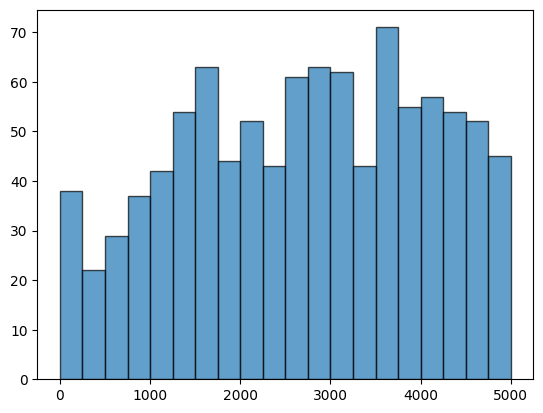

In [32]:
plt.hist(doc_lengths, bins=20, edgecolor='black', alpha=0.7, range=[0,5000])
plt.show()

#### TODO
- need to store chunked data into vectorDB
  - start with no chunking (just embed entire markdown document); if doc size is too long for embedding model, truncate down the document
    - to improve this, we can chunk long documents based on RecursiveTextSplitter or by chunking based on section of a markdown document (but not entirely sure how to do this)
    - can try semantic chunking after this
- define retrievers
- define prompt for RAG
- define graph for RAG
- evaluate RAG and measure results

In [15]:
import aiohttp
import asyncio
import nest_asyncio
import os
from dotenv import load_dotenv
from typing import List, Dict, Any, Tuple, Union
import json
from github import Github, Auth
from gidgethub.aiohttp import GitHubAPI
from gidgethub import GitHubException
import sys
import base64
from stamina import retry, retry_context
import re
from functools import partial
from textacy import preprocessing
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
from qdrant_client.http.models import Distance, VectorParams
import uuid
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate
from langgraph.graph import START, StateGraph
from langchain_core.documents import Document
from typing_extensions import List, TypedDict

import numpy as np
import matplotlib.pyplot as plt

# allow for multiple event loops within Jupyter
nest_asyncio.apply()

# load environment variables
load_dotenv()

import pickle

In [2]:
# Load (unpickle) from the file
with open("github_data.pkl", "rb") as f:
    starred_repo_data = pickle.load(f)

In [3]:
def strip_markdown(text: str) -> str:
    """Remove common Markdown syntax; keep inner text and emojis."""
    # Headings: ## Title -> Title
    text = re.sub(r"^#{1,6}\s*", "", text, flags=re.MULTILINE)
    # Inline code: `code` -> code
    text = re.sub(r"`([^`]+)`", r"\1", text)
    # Bold/italic: **bold** or *italic* -> bold / italic
    text = re.sub(r"\*{1,2}([^*]+)\*{1,2}", r"\1", text)
    text = re.sub(r"_{1,2}([^_]+)_{1,2}", r"\1", text)
    # Link markup: [text](url) -> text
    text = re.sub(r"\[([^\]]+)\]\([^)]+\)", r"\1", text)
    # Collapse many newlines
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text


def make_normalize_text_pipeline(
    *,
    url_repl: str = "",
    unicode_form: str = "NFC",
):
    """
    Build a textacy pipeline: Markdown/HTML → plain text (emojis kept).

    Args:
        url_repl: Replacement for URLs (default ""). Use "_URL_" to keep a placeholder.
        unicode_form: Unicode normalization form ("NFC", "NFD", "NFKC", "NFKD"). Default "NFC".

    Returns:
        A callable that takes a string and returns preprocessed plain text.
    """
    return preprocessing.make_pipeline(
        strip_markdown,
        preprocessing.remove.html_tags,
        preprocessing.normalize.bullet_points,
        preprocessing.normalize.quotation_marks,
        partial(preprocessing.normalize.unicode, form=unicode_form),
        preprocessing.normalize.whitespace,
    )


# Default pipeline instance
normalize_text_pipeline = make_normalize_text_pipeline()

In [4]:
# define embedding model for vector store
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
MAX_CHARACTERS = 30_000  # fall-back for when text is too long

In [31]:
NAMESPACE = uuid.NAMESPACE_URL

def repo_to_uuid(repo_name: str) -> str:
    return str(uuid.uuid5(NAMESPACE, repo_name))

def normalize_docs(docs: List[Dict[str, Any]]):
    content_str = ''
    for doc in docs:
        content_str += (doc['content'] + '\n\n')
    truncated = content_str[:MAX_CHARACTERS] if len(content_str) > MAX_CHARACTERS else content_str
    normalized_text = normalize_text_pipeline(truncated)
    return normalized_text


def organize_repo_data(repo_data: Dict[Any, Any]) -> Tuple[List[str], List[Dict[str, Union[str, int]]], List[str]]:
    ids = []
    metadata = []
    docs = []
    for repo in repo_data:
        id = repo_to_uuid(repo['repo'])
        description = repo['description']
        doc_source = repo['doc_source']
        stars = repo['stars']
        url = repo['url']
        language = repo['language']
        # append to lists for DB consumption
        ids.append(id)
        metadata.append({
            'id': id,
            'repo': repo['repo'],
            'description': description,
            'language': language,
            'doc_source': doc_source,
            'stars': stars,
            'url': url,
        })
        docs.append(normalize_docs(repo['docs']))
    return ids, metadata, docs

In [32]:
ids, metadata, docs = organize_repo_data(starred_repo_data)

In [33]:
print(f"id: {ids[0]}\n\nmetadata: {metadata[0]}\n\ndocs:\n {docs[0]}")

id: fe78755d-8274-5e64-8be5-2ef7ebc4149b

metadata: {'id': 'fe78755d-8274-5e64-8be5-2ef7ebc4149b', 'repo': 'chartbeat-labs/textacy', 'description': 'NLP, before and after spaCy', 'language': 'Python', 'doc_source': 'readme', 'stars': 2235, 'url': 'https://github.com/chartbeat-labs/textacy'}

docs:
 textacy: NLP, before and after spaCy
textacy is a Python library for performing a variety of natural language processing (NLP) tasks, built on the high-performance spaCy library. With the fundamentals --- tokenization, part-of-speech tagging, dependency parsing, etc. --- delegated to another library, textacy focuses primarily on the tasks that come before and follow after.
![build status](https://travis-ci.org/chartbeat-labs/textacy)
![current release version](https://github.com/chartbeat-labs/textacy/releases)
![pypi version](https://pypi.python.org/pypi/textacy)
![conda version](https://anaconda.org/conda-forge/textacy)
features
- Access and extend spaCy's core functionality for working wi

In [34]:
# build in-memory vector store # and load documents (repo content and metadata associated)
client = QdrantClient(":memory:")
client.create_collection(
    collection_name="ask_my_bookmark",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)

vector_store = QdrantVectorStore(
    client=client,
    collection_name="ask_my_bookmark",
    embedding=embeddings,
)

_ = vector_store.add_texts(texts=docs, ids=ids, metadatas=metadata)

In [35]:
# define retriever
naive_retriever = vector_store.as_retriever(search_kwargs={"k" : 10})

In [36]:
### build RAG graph
def format_context(docs) -> str:
    chunks = []
    for doc in docs:
        meta = doc.metadata
        topics = meta.get('topics', [])
        if topics:
            topics_str = f"Topics: {','.join(topics)}"
        else:
            topics_str = "N/A"
        chunk = f"""---
Repo: {meta.get('repo', 'N/A')}
URL: {meta.get('url', 'N/A')}
Description: {meta.get('description', 'N/A')}
Topics: {topics_str}
Programming Language: {meta.get('language', 'N/A')}
Stars: {meta.get('stars', 'N/A')}

README excerpt:
{doc.page_content.strip()}
---"""
        chunks.append(chunk)
    return "\n\n".join(chunks)


# define the RAG Pipeline in LangChain
RAG_SYSTEM_PROMPT = """
You are AskMyBookmark, a personal research assistant with access to the user's GitHub starred repositories.

Your job is to help the user discover, recall, and explore repositories they have bookmarked on GitHub. You answer questions by reasoning over the retrieved repository context provided to you — not from your general knowledge of what exists on GitHub.

**Ground rules:**
- Only surface repositories that appear in the retrieved context below. Do not invent or suggest repositories that are not present in the context.
- If no retrieved repositories are relevant to the query, say so honestly and suggest the user try rephrasing or broadening their search.
- You may use your general knowledge to explain a topic or technology, but all repository recommendations must come exclusively from the retrieved context.

**When presenting results:**
- Always include the repository's full name (Repo) as a markdown link to its GitHub URL: [Repo](URL)
- Include a brief description of what the repo does (from the description and topics fields), written in your own words if the original description is terse or absent.
- Explain in 1–2 sentences *why* this repository is relevant to the user's query — this is the most important part.
- Group or rank results by relevance if there are several.
- If useful, note the primary programming language, star count, or topics to help the user evaluate the match.

**Tone:** Conversational, concise, and helpful. Treat the user as a developer who starred these repos intentionally and wants quick, intelligent recall — not a tutorial.

---

Retrieved repository context:
{context}
"""

rag_prompt = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template(RAG_SYSTEM_PROMPT),
    HumanMessagePromptTemplate.from_template("{question}"),
])
llm = ChatOpenAI(model="gpt-4.1-nano")

def generate(state):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = rag_prompt.format_messages(question=state["question"], context=docs_content)
    response = llm.invoke(messages)
    return {"response" : response.content}

class State(TypedDict):
    question: str
    context: List[Document]
    response: str

def retrieve(state):
    retrieved_docs = naive_retriever.invoke(state["question"])
    return {"context" : retrieved_docs}

# build graph
rag_graph_builder = StateGraph(State).add_sequence([retrieve, generate])
rag_graph_builder.add_edge(START, "retrieve")
rag_graph = rag_graph_builder.compile()

In [21]:
response = rag_graph.invoke({"question" : "Do I have any starred repositories related to Bayesian Statistics or Bayesian Modeling?"})

In [23]:
print(response['response'])

Yes, you do have starred repositories related to Bayesian Statistics and Bayesian Modeling. Here are the relevant ones:

1. [bayes-toolbox](https://github.com/psf/black)  
   - This Python package provides tools for sophisticated Bayesian analyses, making Bayesian modeling more straightforward. It's relevant because it offers practical tools for Bayesian statistics in Python, aligning with your interest in Bayesian modeling.

2. [Bayesian Modeling and Computation in Python](https://github.com/martinOsvaldo/bayesian-computation-python)  
   - This repository contains open-access code and examples from a book on Bayesian modeling and computation using Python. It's highly relevant as it covers Bayesian methods, probabilistic programming, and includes updated code for Bayesian analysis in Python.

3. [Bayesian-Analysis-with-Python-Second-Edition](https://github.com/PacktPublishing/Bayesian-Analysis-with-Python-Second-Edition)  
   - This repository accompanies a book on Bayesian analysis w

In [24]:
response2 = rag_graph.invoke({"question" : "Yes, can you tell me more about the PyMC resources repository (#4)?"})

In [25]:
print(response2['response'])

Certainly! The PyMC Resources repository is a collection of educational materials aimed at helping users learn Bayesian statistics and data science using Python and PyMC. It features well-documented workflows tailored for students and professionals, designed to simplify the learning process by providing practical examples and step-by-step guides.

The repository includes:
- Demonstrations and tutorials that cover fundamental concepts in data science, geostatistics, and machine learning.
- Code examples for applying models in various domains, especially subsurface data analysis.
- Resources to support lecture notes, hands-on activities, and model exploration, making complex concepts more accessible.

It's authored by Michael Pyrcz, a professor at The University of Texas at Austin, with a focus on subsurface modeling, data analytics, and machine learning. The content is aimed at both beginners and advanced users, facilitating experiential learning through practical Python workflows.

Wou

In [26]:
response3 = rag_graph.invoke({"question" : "What are some top deep learning libraries that I have starred on github?"})

In [27]:
print(response3['response'])

Based on your starred repositories, some top deep learning libraries include:

- [DeepMatch](https://github.com/shenweichen/deepmatch): A library for deep matching models used in recommendation and advertising, supporting models like FM, DSSM, NCF, and more. It's designed for training complex models and exporting user and item vectors for ANN search.

- [Deep Lake](https://github.com/activeloopai/deeplake): A versatile database optimized for AI and deep learning, supporting large-scale data storage, versioning, and integration with frameworks like PyTorch and TensorFlow.

- [PyTorch](https://github.com/pytorch/pytorch): The widely used dynamic neural network framework with strong GPU support.

- [TensorFlow](https://github.com/tensorflow/tensorflow): Google's popular open-source framework for machine learning and deep neural networks.

- [Keras](https://github.com/keras-team/keras): High-level API for deep learning, running on top of TensorFlow.

- [Flax](https://github.com/google/flax

In [28]:
response4 = rag_graph.invoke({"question" : "Can you tell me how many times the PyTorch Library has been starred on Github versus the Tensorflow library?"})
print(response4['response'])

I can only reference the repository information I have retrieved. According to that:

- The PyTorch library ([owner/repo](https://github.com/pytorch/pytorch)) has approximately 94K stars.
- The TensorFlow library ([owner/repo](https://github.com/tensorflow/tensorflow)) has around 200K stars.

So, on GitHub, TensorFlow has significantly more stars than PyTorch based on the latest available data.


In [29]:
response5 = rag_graph.invoke({"question" : "What are the top ""awesome"" github repositories that I have starred?"})
print(response5['response'])

Based on your starred repositories, the top ones include:

1. [Awesome-Kubernetes](https://github.com/sindresorhus/awesome)  
A curated list of outstanding Kubernetes resources, covering everything from basics to advanced topics, along with tutorials, workflows, and community contributions. This is highly relevant if you're into cloud orchestration and container management.

2. [Antigravity Awesome Skills](https://github.com/sickn33/antigravity-awesome-skills)  
A comprehensive collection of AI coding skills and tools designed for various AI assistants like Claude, Gemini, and Copilot. It’s essential if you're working with AI, ML, and automation workflows.

3. [Awesome Hadoop](https://github.com/sindresorhus/awesome) (listed as part of a Hadoop ecosystem collection)  
A curated list of Hadoop andBig Data ecosystem resources, ideal for data engineers or those working with distributed systems and large-scale data processing.

4. [Awesome Deep Learning Project Ideas](https://github.com/si

In [30]:
response6 = rag_graph.invoke({"question" : "What are the top machine learning repositories I have starred?"})
print(response6['response'])

Based on your starred repositories, two notable top repositories are:

1. **Complete Machine Learning Package**   
   [owner/repo](https://github.com/owner/repo) (full name not specified here)  
   This is a comprehensive collection of notebooks and tools covering classical machine learning, deep learning, data manipulation, visualization, and MLOps. It is ranked as one of the top data science repositories on GitHub, containing 35 notebooks designed for practical learning and project building.  
   The repository's popularity and extensive content make it a top resource for machine learning practitioners.

2. **Awesome Machine Learning and AI Courses**  
   [owner/repo](https://github.com/owner/repo) (full name not specified)  
   A curated list of high-quality, free machine learning and AI courses with video lectures from top universities and institutions. It is a go-to resource for beginners and advanced learners alike, offering courses on foundational topics, deep learning, NLP, rei

In [37]:
response7 = rag_graph.invoke({"question" : "Do I have any starred repositories related to Bayesian Statistics or Bayesian Modeling?"})
print(response7['response'])

Yes, you do have starred repositories related to Bayesian Statistics and Bayesian Modeling. Here are the relevant ones:

- [bayes-toolbox](https://github.com/psf/black): This Python package simplifies running sophisticated Bayesian analyses. Its focus on Bayesian statistics makes it highly relevant if you're interested in Bayesian modeling, especially for statistical analysis and inference.

- [Bayesian Modeling and Computation in Python](https://github.com/martinosvaldo/bayesian-modeling): This repository includes open-access code and scripts from a book on Bayesian modeling in Python. It's directly related to Bayesian modeling techniques and practical implementation.

- [Bayesian-Analysis-with-Python-Second-Edition](https://github.com/packtpub/bayesian-analysis-with-python-second-edition): This appears to be an older project related to a book on Bayesian analysis using Python, focusing on applied Bayesian inference with PyMC3 and ArviZ.

- [PyMC Resources](https://github.com/pymc-dev

In [38]:
response8 = rag_graph.invoke({"question" : "Can you give me any repositories related to Bayesian modeling that are not book or textbook exercises/resources?"})
print(response8['response'])

Based on your starred repositories, I see two relevant repositories related to Bayesian modeling that are not primarily book or textbook exercises:

1. [bayes-toolbox](https://github.com/kim-hyosub/bayes-toolbox)  
   - This is a Python package designed for running sophisticated Bayesian analyses in a straightforward manner. It provides tools for Bayesian statistics, making it a practical library for implementing Bayesian models and inference.  
   - Why relevant? It offers a software tool for Bayesian modeling that can be used directly in projects, beyond educational resources.

2. [Bayesian-Analysis-with-Python-Second-Edition](https://github.com/avehtari/Bayesian-Analysis-with-Python-Second-Edition)  
   - Although this repository supports a book, it also contains actual code and materials for applied Bayesian inference in Python using PyMC3 and ArviZ, focusing on implementation rather than textbook exercises.  
   - Why relevant? It's a practical implementation resource for Bayesian

In [39]:
response9 = rag_graph.invoke({"question" : "Do I have any R programming libraries or packages starred on github?"})
print(response9['response'])

Based on the retrieved repositories, I see that you have at least one R package starred:

- [Polars for R](https://github.com/rstudio/cheatsheets/blob/master/data-visua) (related to Polars, which has R support). While this is a cheatsheet repository, it references R packages and resources, but I don't see a specific starred R package for Polars in your list.

Additionally, there's [rpolars for R](https://github.com/rpolars for R), a dedicated R package to use Polars DataFrame in R, which is likely relevant if you are interested in R-focused data manipulation with Polars.

Would you like me to focus on other R packages or resources in your starred repositories?


In [40]:
response10 = rag_graph.invoke({"question" : "Are those the only 2 R programming language repositories that I have starred?"})
print(response10['response'])

Based on the retrieved context, I only see references to the R programming language in the "Cheat Sheets" section and in various other data science and statistical resources, but there are no specific GitHub repositories related to R listed among your starred repositories. Therefore, I cannot confirm that these are the only R repositories you've starred, and it appears that no specific R-related repositories are included in the list provided. 

Would you like me to double-check or help you look for other R repositories?


In [45]:
for i, doc in enumerate(response7['context']):
    print(i, doc)

0 page_content='StatisticalModeling
This repository incluldes Python/R sciripts for statistical modeling. This is mostly for personal use.' metadata={'id': 'e721a9bf-8fee-5b98-9cbe-d4a38c1c3c91', 'repo': 'kidaufo/StatisticalModeling', 'description': 'Statistical modeling and Bayesian modeling by PyMC3, Stan and TensorFlow Probability', 'language': 'Jupyter Notebook', 'doc_source': 'readme', 'stars': 23, 'url': 'https://github.com/kidaufo/StatisticalModeling', '_id': 'e721a9bf-8fee-5b98-9cbe-d4a38c1c3c91', '_collection_name': 'ask_my_bookmark'}
1 page_content='![DOI](https://doi.org/10.21105/joss.05526)
![DOI](https://zenodo.org/badge/latestdoi/553182204) 
!coverage
![Code style: black](https://github.com/psf/black)
bayes-toolbox 
bayes-toolbox (aka, Bayesian Statistics Toolbox [BST]) is a Python package for running sophisticated Bayesian analyses in a simple, straight forward manner. 
Documentation
The documentation for bayes-toolbox is hosted here.
Installation 
![PyPI version](https:

#### TODO
- let's also add more metadata such as topics into the metadata & embeddings (DO THIS RIGHT AWAY)
- so far I've just been utilizing naive retrieval; let's try a hybrid search approach utilize and ensemble retriever (dense vector retrieval + BM25 retrieval with reranking at the end w/Cohere)
- let's increase K from 10 to 20 (10 from each retriever) and experiment with what values give us the best results
- then let's try a different chunking strategy
  - right now
- maybe we can experiment with searching on multiple fields rather than just the README or top level markdown docs retrieved from a github repo..
- try utilizing Ollama embedding models & Ollama LLMs (time-permitting)